In [ ]:
"""
Loading wandb artifact locally
"""

In [ ]:
import wandb
import os

os.environ['WANDB_MODE']='online'
run = wandb.init()
artifact = run.use_artifact('lazare-rd-universit-paris-saclay/spec2selfies/run-gvmdkmpm-history:v0', type='wandb-history')
#artifact = run.use_artifact('lazare-rd-universit-paris-saclay/uncategorized/run-4pe94nrn-history:v0', type='wandb-history')
artifact_dir = artifact.download()

In [37]:
import pandas as pd

df = pd.read_parquet('./artifacts/run-gvmdkmpm-history:v0/0000.parquet')
df

,num_beams,eval_sis_step_0,_runtime,num_seq_beams,eval_sis_step_1,eval_sis_step_2,eval_sis_step_3,_step,num_steps,_timestamp,std_eval_sis,mean_eval_sis,outputs_saves
0,15.0,NaN,19.063383,15.0,NaN,NaN,NaN,0.0,3.0,1.751462e+09,NaN,NaN,/lustre/fsn1/projects/rech/aik/unh74gq/cache/v...
1,NaN,0.540391,35.261038,NaN,0.754946,0.843616,0.842195,1.0,NaN,1.751462e+09,NaN,NaN,None
2,NaN,0.593562,50.247737,NaN,0.705039,0.812426,0.818191,2.0,NaN,1.751462e+09,NaN,NaN,None
3,NaN,0.705775,59.673955,NaN,0.838039,0.858117,0.857039,3.0,NaN,1.751462e+09,NaN,NaN,None
4,NaN,0.603994,73.148640,NaN,0.780036,0.811826,0.832276,4.0,NaN,1.751462e+09,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1734,NaN,0.556234,22008.904747,NaN,0.682984,0.693009,0.694093,1734.0,NaN,1.751484e+09,NaN,NaN,None
1735,NaN,0.606772,22017.080503,NaN,0.697985,0.699156,0.698001,1735.0,NaN,1.751484e+09,NaN,NaN,None
1736,NaN,0.499742,22024.820427,NaN,0.669799,0.683970,0.682484,1736.0,NaN,1.751484e+09,NaN,NaN,None
1737,NaN,0.646340,22029.925587,NaN,0.723761,0.726324,0.728160,1737.0,NaN,1.751484e+09,NaN,NaN,None


In [ ]:
"""
Loading data when there is no artifact
"""

In [29]:
import wandb
api = wandb.Api()
#run = api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/r4axvvph") #SELFormer_PerfectModel
#run = api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/5ancgyi5") #SELFormer_WithFormula
#run = api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/84rhj99b") #SELFormer_PerfectModel_WithFormula
#run = api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/42bh0x3k") #ogSELFormer_PerfectModel_WithFormula
#run = api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/jc9zlhur") #ogSELFormer_PerfectModel
#run = api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/80wx7t3c") #SELFormer

dico = {
    "SELFormer_WithFormula" : api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/5ancgyi5"),
    "SELFormer" : api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/80wx7t3c"),
    "ogSELFormer_PerfectModel" : api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/jc9zlhur"),
    "ogSELFormer_PerfectModel_WithFormula" : api.run("lazare-rd-universit-paris-saclay/spec2selfies_eval/42bh0x3k"),
}

In [2]:
"""
Reading and displaying data
"""

'\nReading and displaying data\n'

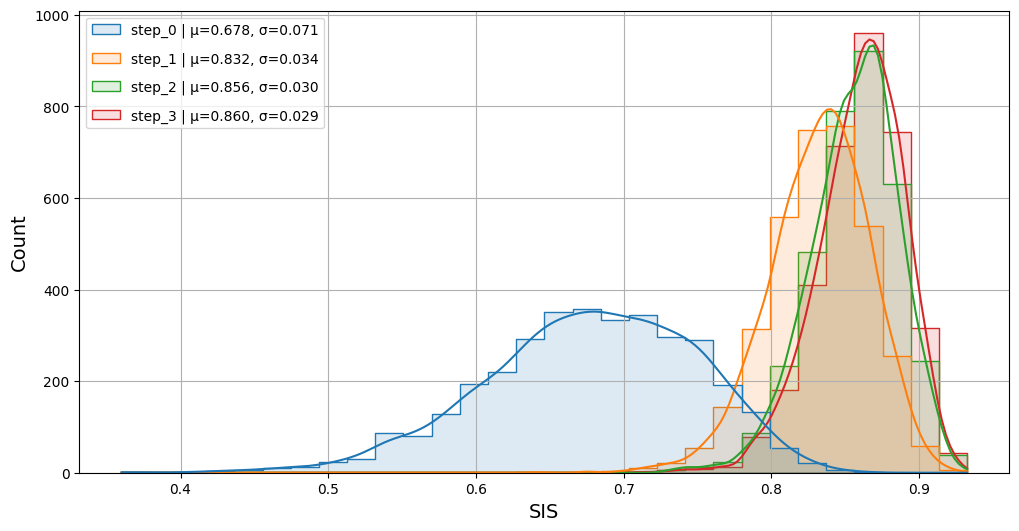

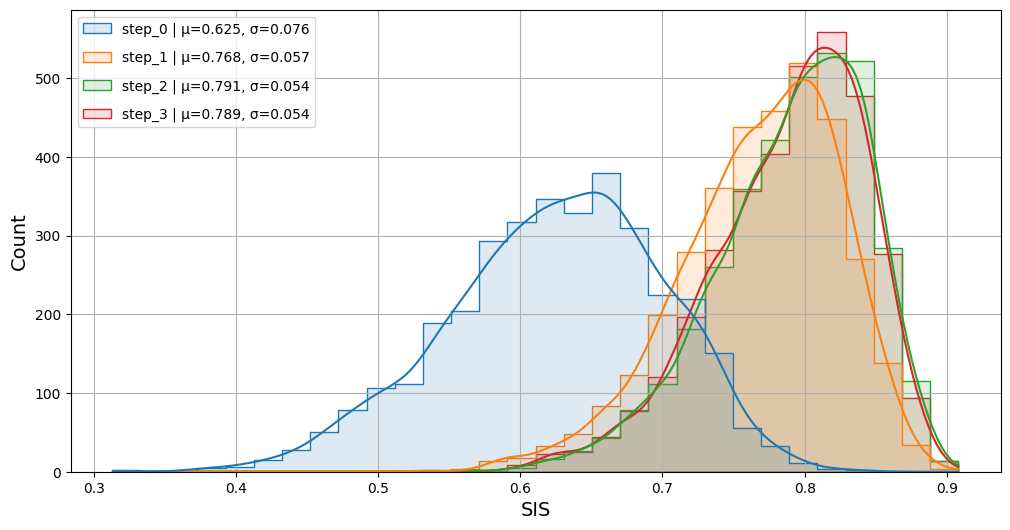

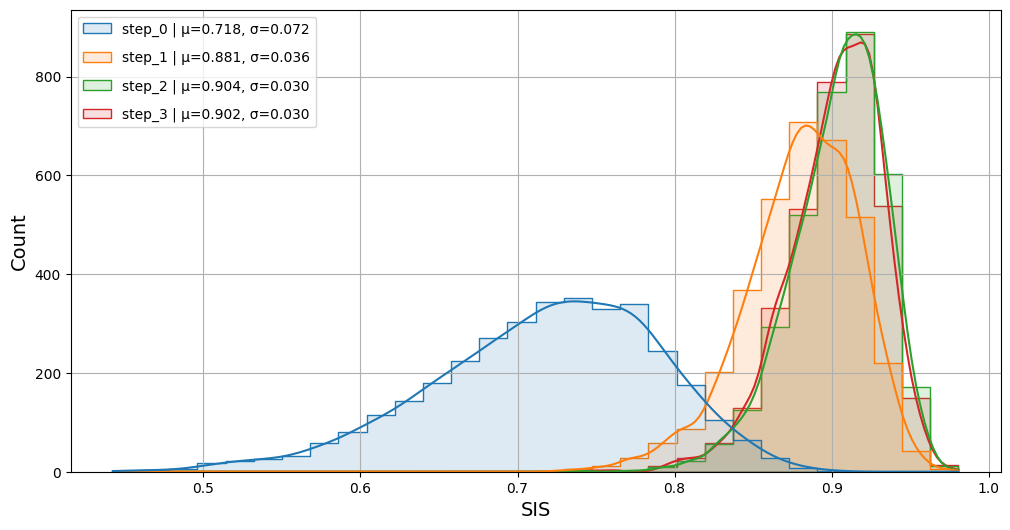

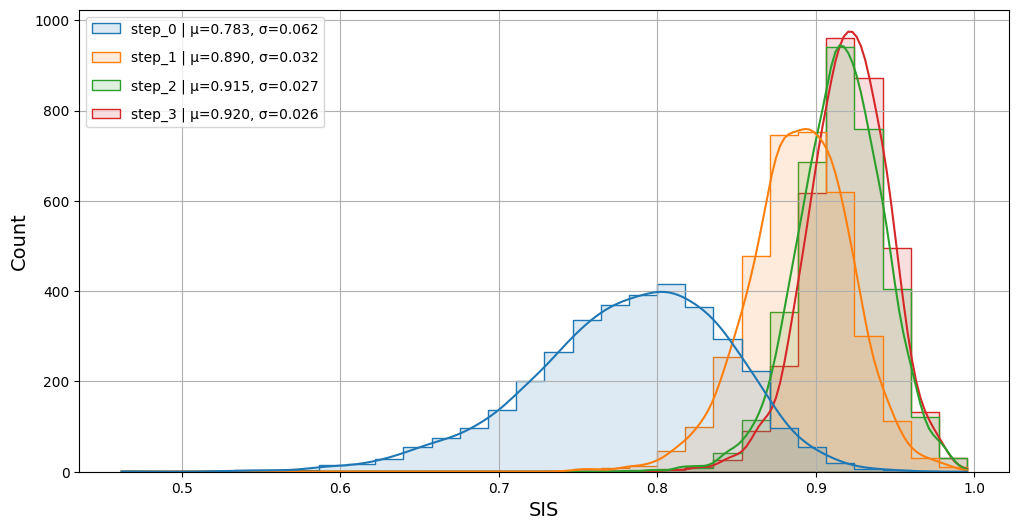

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

for name, run in dico.items():
    df = run.history(samples=10000)

    df_clean = df[["eval_sis_step_0", "eval_sis_step_1", "eval_sis_step_2", "eval_sis_step_3"]]
    #df_clean = df[["eval_sis_step_2", "eval_sis_step_3"]]
    df_clean = df_clean.dropna()
    stats = df_clean.agg(["mean", "std"]).T
    
    # Melt dataframe for plotting
    df_long = df_clean.melt(
        var_name="step", value_name="value"
    )
    
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data=df_long,
        x="value",
        hue="step",
        alpha=0.15,
        bins=30,
        kde=True,
        element="step",
        stat="count",
        common_norm=False,
        legend=True,
    )
    
    # ---- Customize legend with mean & std ----
    leg = ax.get_legend()
    handles = leg.legend_handles
    labels = [t.get_text() for t in leg.texts]
    new_labels = []
    for lab in labels:
        mean = stats.loc[lab, "mean"]
        std = stats.loc[lab, "std"]
        new_labels.append(f"{lab[9:]} | μ={mean:.3f}, σ={std:.3f}")
    
    ax.legend(
        handles,
        new_labels,
        title="",
        fontsize=10,
        labelspacing=1,
    )
    
    plt.xlabel("SIS", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.grid(True)
    
    fig = ax.get_figure()
    fig.savefig(f"./data/eval/figures/{name}_SIS.png", dpi=300, bbox_inches='tight')

    #plt.show()

In [ ]:
'''
Molecules similarities
'''

In [ ]:
'''
Logs management
'''

In [23]:
from spec2selfies.eval_utils import load_logs
from transformers import AutoTokenizer
import torch
from tqdm import tqdm

[2025-08-25 14:37:36,514] [WARNING] [real_accelerator.py:209:get_accelerator] Setting accelerator to CPU. If you have GPU or other accelerator, we were unable to detect it.
[2025-08-25 14:37:36,548] [INFO] [real_accelerator.py:254:get_accelerator] Setting ds_accelerator to cpu (auto detect)


/usr/bin/ld: cannot find -laio
clang-15: error: linker command failed with exit code 1 (use -v to see invocation)


[2025-08-25 14:37:46,766] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


In [24]:
valid_logs = ['text_ids', 'embeddings', 'spectras', 'bm_spectra', 'scores', 'initial_score', 'bm_text_ids', 'formulas', 'bm_formula']


GLOBAL_LOGS_PATH = "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/likely-amazed-pigeon" # ogSELFormer_PerfectModel_WithFormula
#GLOBAL_LOGS_PATH = "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/namely-mutual-fawn" # SELFormer_PerfectModel_WithFormula
#GLOBAL_LOGS_PATH = "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/subtly-vocal-stag" # SELFormer_WithFormula
#GLOBAL_LOGS_PATH = "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/purely-casual-maggot" # SELFormer_PerfectModel

LOGS_PATHS = {
    "SELFormer_PerfectModel_WithFormula" : "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/namely-mutual-fawn",
    "SELFormer_WithFormula" : "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/subtly-vocal-stag",
    "SELFormer" : "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/widely-finer-marmot",
    "SELFormer_PerfectModel" : "/lustre/fsn1/projects/rech/aik/unh74gq/cache/vec2text/eval/purely-casual-maggot"
}

tokenizer = AutoTokenizer.from_pretrained("./data/saved_models/Inverter__30epochs__encoder_decoder_frozen/checkpoint-15411")

def decode_text_ids(text_ids, _id=0, step=0, beam=0): 
    if len(text_ids.shape) <= 2:
        decoded = tokenizer.decode(text_ids[_id,:].astype('uint8'), skip_special_tokens=True)
    else :
        decoded = tokenizer.decode(text_ids[_id, step, beam, :], skip_special_tokens=True)
    return decoded

def load(_type, LOGS_PATH=None):
    assert _type in valid_logs
    if LOGS_PATH is None:
        LOGS_PATH = GLOBAL_LOGS_PATH
    path = f"{LOGS_PATH}/{_type}"
    return load_logs(path)

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from ctypes import ArgumentError

import selfies as sf
from IPython.display import display
from collections import Counter

def draw_mol(selfies: str, label: str):
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol, legend=label)
    display(img)

def get_mol(selfies: str):
    smiles = sf.decoder(selfies)
    return Chem.MolFromSmiles(smiles)

def get_sim(mol1, mol2):
    fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
    try:
        fps1 = fpgen.GetFingerprint(mol1)
        fps2 = fpgen.GetFingerprint(mol2)
        #sim = DataStructs.TanimotoSimilarity(fps1,fps2)
        #sim = DataStructs.DiceSimilarity(fps1,fps2)
        #sim = DataStructs.SokalSimilarity(fps1,fps2)
        #sim = DataStructs.RusselSimilarity(fps1,fps2)
        #sim = DataStructs.KulczynskiSimilarity(fps1,fps2)
        #sim = DataStructs.McConnaugheySimilarity(fps1,fps2)
        sim = DataStructs.CosineSimilarity(fps1,fps2)
    except Exception:
        sim = 0

    return sim

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

beam = 0
df = full_df[[f"step_{i}_beam_{beam}" if i != 0
         else "step_0"
         for i in range(4)]]

df = df.melt(
    var_name="", value_name="value"
)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="value",
    hue="",
    alpha=0.15,
    bins=30,
    kde=True,
    element="step",  
    stat="count",  
    common_norm=False,
)
plt.title("Histogram comparison of eval_sis_X")
plt.xlabel("Value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [3]:
'''
Molecules similarities
'''

'\nMolecules similarities\n'

In [9]:
from datasets import load_from_disk
dataset = load_from_disk("./data/scaffold_split_merged_spectra/arrow/tokenized_datasets/test")

In [21]:
from tqdm import tqdm

indexes = []
for i in tqdm(range(len(dataset))):
    selfies = dataset['selfies'][i]
    mol = get_mol(selfies)
    nb = mol.GetNumHeavyAtoms()
    if nb<=13 and nb>=6:
        indexes.append(nb)

100%|██████████| 13892/13892 [03:33<00:00, 65.11it/s]


In [22]:
print (len(indexes))

2103


In [1]:
import pandas as pd

#full_df = pd.read_csv("data/eval/SELFormer_PerfectModel.csv")
#full_df = pd.read_csv("data/eval/SELFormer_PerfectModel_WithFormula.csv")
#full_df = pd.read_csv("data/eval/SELFormer_WithFormula.csv")
full_df = pd.read_csv("data/eval/ogSELFormer_PerfectModel_WithFormula.csv")
#full_df = pd.read_csv("data/eval/SELFormer.csv")
#full_df = pd.read_csv("data/eval/ogSELFormer_PerfectModel.csv")

print (full_df.columns)
print (len(full_df))

Index(['step_0', 'step_1_beam_0', 'step_1_beam_1', 'step_1_beam_2',
       'step_1_beam_3', 'step_1_beam_4', 'step_1_beam_5', 'step_1_beam_6',
       'step_1_beam_7', 'step_1_beam_8', 'step_1_beam_9', 'step_1_beam_10',
       'step_1_beam_11', 'step_1_beam_12', 'step_1_beam_13', 'step_1_beam_14',
       'step_2_beam_0', 'step_2_beam_1', 'step_2_beam_2', 'step_2_beam_3',
       'step_2_beam_4', 'step_2_beam_5', 'step_2_beam_6', 'step_2_beam_7',
       'step_2_beam_8', 'step_2_beam_9', 'step_2_beam_10', 'step_2_beam_11',
       'step_2_beam_12', 'step_2_beam_13', 'step_2_beam_14', 'step_3_beam_0',
       'step_3_beam_1', 'step_3_beam_2', 'step_3_beam_3', 'step_3_beam_4',
       'step_3_beam_5', 'step_3_beam_6', 'step_3_beam_7', 'step_3_beam_8',
       'step_3_beam_9', 'step_3_beam_10', 'step_3_beam_11', 'step_3_beam_12',
       'step_3_beam_13', 'step_3_beam_14'],
      dtype='object')
13892


In [42]:
import pandas as pd

l_rdkit_cosine = {
    "SELFormer": pd.read_csv("data/eval/SELFormer.csv"), 
    "ogSELFormer_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel.csv"),
    "SELFormer_WithFormula": pd.read_csv("data/eval/SELFormer_WithFormula.csv"),
    "ogSELFormer_WithFormula_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_WithFormula.csv")
}

l_rdkit_tan = {
    "SELFormer": pd.read_csv("data/eval/SELFormer_rdkit_tan.csv"), 
    "ogSELFormer_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_rdkit_tan.csv"),
    "SELFormer_WithFormula": pd.read_csv("data/eval/SELFormer_WithFormula_rdkit_tan.csv"),
    "ogSELFormer_WithFormula_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_WithFormula_rdkit_tan.csv")
}

l_ecfp4_cosine = {
    "SELFormer": pd.read_csv("data/eval/SELFormer_ecfp4_cosine.csv"), 
    "ogSELFormer_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_ecfp4_cosine.csv"),
    "SELFormer_WithFormula": pd.read_csv("data/eval/SELFormer_WithFormula_ecfp4_cosine.csv"),
    "ogSELFormer_WithFormula_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_WithFormula_ecfp4_cosine.csv")
}

l_ecfp4_tan = {
    "SELFormer": pd.read_csv("data/eval/SELFormer_ecfp4_tan.csv"), 
    "ogSELFormer_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_ecfp4_tan.csv"),
    "SELFormer_WithFormula": pd.read_csv("data/eval/SELFormer_WithFormula_ecfp4_tan.csv"),
    "ogSELFormer_WithFormula_PM": pd.read_csv("data/eval/ogSELFormer_PerfectModel_WithFormula_ecfp4_tan.csv")
}


In [3]:
'''
Visualisation similarities
'''

'\nVisualisation similarities\n'

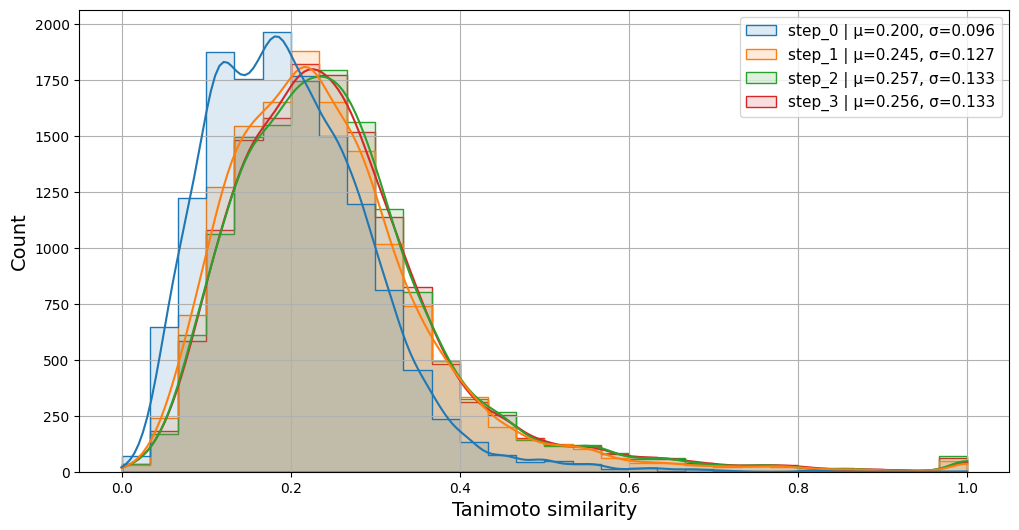

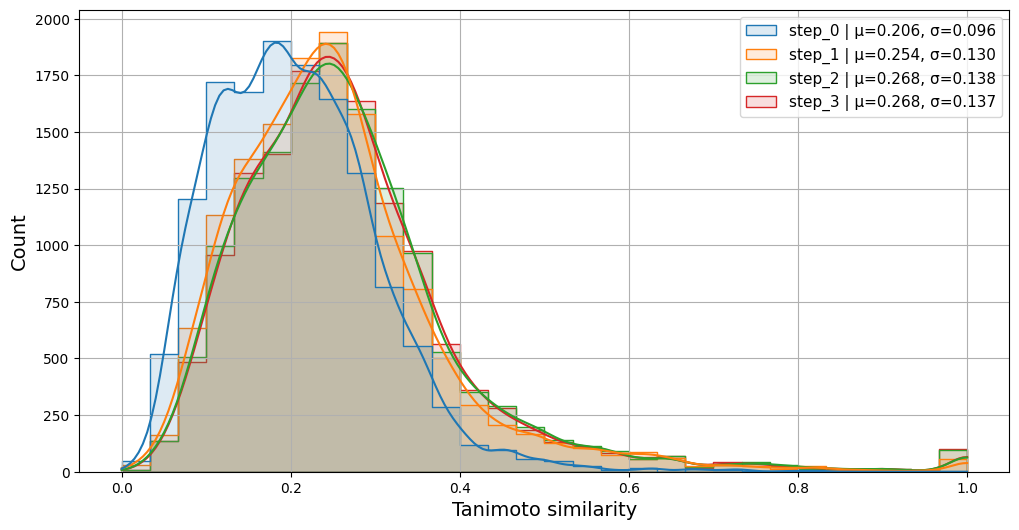

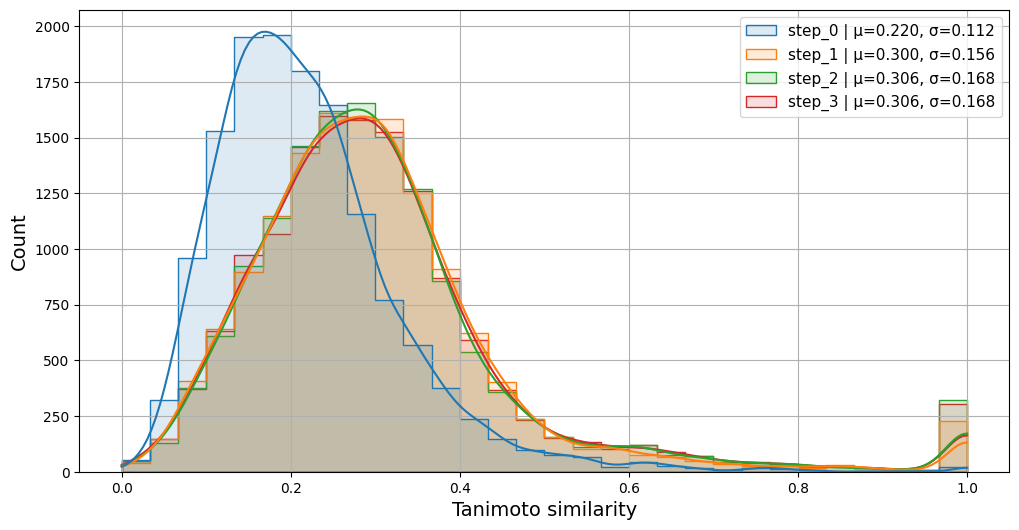

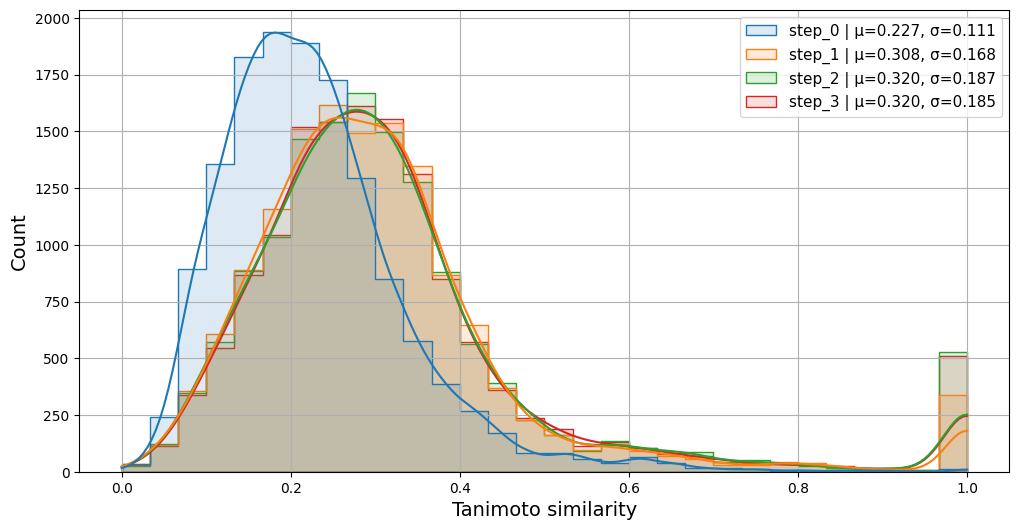

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

l = l_rdkit_tan

for name, full_df in l.items():

    beam = 0
    df = full_df[[f"step_{i}_beam_{beam}" if i != 0
             else "step_0"
             for i in range(4)]]

    #df = df.loc[indexes]

    stats = df.agg(["mean", "std"]).T

    
    
    df = df.melt(
        var_name="source", value_name="value"
    )
    
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data=df,
        x="value",
        hue="source",
        alpha=0.15,
        bins=30,
        kde=True,
        element="step",  
        stat="count",  
        common_norm=False,
    )
    
    leg = ax.get_legend()
    handles = leg.legend_handles
    labels = [t.get_text() for t in leg.texts]
    new_labels = []
    for lab in labels:
        mean = stats.loc[lab, "mean"]
        std = stats.loc[lab, "std"]
        new_labels.append(f"{lab[:6]} | μ={mean:.3f}, σ={std:.3f}")
    
    ax.legend(handles, new_labels, title="", fontsize=11)
    
    plt.xlabel("Tanimoto similarity", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    #plt.title(name)
    plt.grid(True)
    
    fig = ax.get_figure()
    fig.savefig(f"./data/eval/figures/simils_{name}_rdkit_tan.png", dpi=300, bbox_inches='tight')

In [111]:
count = 0
top = 15
lim = 1
columns = [f"step_{i}_beam_{j}" if i != 0
            else "step_0"
            for i in range(4)
            for j in range(top)
          ]

indexes = []
for i in range (len(full_df)):
    found = False
    for step in range (4):
        for beam in range(top):
            col = f"step_{step}_beam_{beam}" if step != 0 else "step_0"
            if full_df[col][i] >= lim and not found:
                count+=1
                found = True
                indexes.append(i)
                
print (count)
print (indexes)

676
[366, 385, 392, 395, 597, 598, 599, 661, 671, 947, 948, 954, 967, 1003, 1012, 1013, 1037, 1044, 1083, 1122, 1132, 1134, 1151, 1164, 1173, 1188, 1191, 1192, 1201, 1205, 1210, 1222, 1239, 1255, 1257, 1270, 1271, 1276, 1280, 1282, 1292, 1298, 1300, 1319, 1323, 1333, 1347, 1362, 1364, 1371, 1379, 1393, 1396, 1441, 1445, 1471, 1480, 1483, 1500, 1518, 1522, 1526, 1532, 1537, 1541, 1543, 1564, 1566, 1578, 1591, 1600, 1605, 1627, 1635, 1658, 1667, 1673, 1687, 1691, 1703, 1744, 1746, 1747, 1757, 1760, 1769, 1772, 1775, 1800, 1808, 1809, 1810, 1815, 1816, 1825, 1829, 1845, 1852, 1853, 1857, 1868, 1884, 1885, 1887, 1898, 1944, 2002, 2019, 2024, 2097, 2351, 2354, 2356, 2368, 2373, 2397, 2407, 2412, 2418, 2422, 2427, 2428, 2437, 2439, 2450, 2466, 2470, 2475, 2481, 2500, 2510, 2517, 2521, 2543, 2545, 2552, 2555, 2557, 2574, 2579, 2585, 2601, 2610, 2613, 2627, 2628, 2629, 2632, 2633, 2644, 2645, 2656, 2670, 2673, 2678, 2679, 2686, 2689, 2693, 2695, 2702, 2780, 2910, 2918, 2921, 2934, 2948, 2949, 

In [10]:
dico = {}
for name, full_df in l.items() :
    top_l = [1, 15]
    lim_l = [1, 0.9, 0.8]
    for lim in lim_l:
        for top in top_l:

            count = 0
            columns = [f"step_{i}_beam_{j}" if i != 0
                    else "step_0"
                    for i in range(4)
                    for j in range(top)
                  ]
        
            indexes = []
            for i in range (len(full_df)):
                found = False
                for step in range (4):
                    for beam in range(top):
                        col = f"step_{step}_beam_{beam}" if step != 0 else "step_0"
                        if full_df[col][i] >= lim and not found:
                            count+=1
                            found = True
                            indexes.append(i)
                            
                found = False
            dico[f"{name}_top{top}_lim{lim}"] = count
print (dico)

{'SELFormer_top1_lim1': 86, 'SELFormer_top15_lim1': 159, 'SELFormer_top1_lim0.9': 155, 'SELFormer_top15_lim0.9': 283, 'SELFormer_top1_lim0.8': 388, 'SELFormer_top15_lim0.8': 742, 'ogSELFormer_PM_top1_lim1': 109, 'ogSELFormer_PM_top15_lim1': 124, 'ogSELFormer_PM_top1_lim0.9': 170, 'ogSELFormer_PM_top15_lim0.9': 249, 'ogSELFormer_PM_top1_lim0.8': 419, 'ogSELFormer_PM_top15_lim0.8': 752, 'SELFormer_WithFormula_top1_lim1': 427, 'SELFormer_WithFormula_top15_lim1': 632, 'SELFormer_WithFormula_top1_lim0.9': 557, 'SELFormer_WithFormula_top15_lim0.9': 923, 'SELFormer_WithFormula_top1_lim0.8': 929, 'SELFormer_WithFormula_top15_lim0.8': 1584, 'ogSELFormer_WithFormula_PM_top1_lim1': 608, 'ogSELFormer_WithFormula_PM_top15_lim1': 676, 'ogSELFormer_WithFormula_PM_top1_lim0.9': 738, 'ogSELFormer_WithFormula_PM_top15_lim0.9': 970, 'ogSELFormer_WithFormula_PM_top1_lim0.8': 1092, 'ogSELFormer_WithFormula_PM_top15_lim0.8': 1613}


In [11]:
i = 0
for name, perf in dico.items():
    print (f"{name} : {perf} / 13892 = {perf/13892}")
    i+=1
    if i%2 == 0:
        print ("\n")

SELFormer_top1_lim1 : 86 / 13892 = 0.006190613302620213
SELFormer_top15_lim1 : 159 / 13892 = 0.011445436222286208


SELFormer_top1_lim0.9 : 155 / 13892 = 0.011157500719838755
SELFormer_top15_lim0.9 : 283 / 13892 = 0.020371436798157214


SELFormer_top1_lim0.8 : 388 / 13892 = 0.027929743737402823
SELFormer_top15_lim0.8 : 742 / 13892 = 0.053412035704002304


ogSELFormer_PM_top1_lim1 : 109 / 13892 = 0.00784624244169306
ogSELFormer_PM_top15_lim1 : 124 / 13892 = 0.008926000575871005


ogSELFormer_PM_top1_lim0.9 : 170 / 13892 = 0.0122372588540167
ogSELFormer_PM_top15_lim0.9 : 249 / 13892 = 0.017923985027353873


ogSELFormer_PM_top1_lim0.8 : 419 / 13892 = 0.030161243881370575
ogSELFormer_PM_top15_lim0.8 : 752 / 13892 = 0.05413187446012093


SELFormer_WithFormula_top1_lim1 : 427 / 13892 = 0.030737114886265477
SELFormer_WithFormula_top15_lim1 : 632 / 13892 = 0.04549380938669738


SELFormer_WithFormula_top1_lim0.9 : 557 / 13892 = 0.04009501871580766
SELFormer_WithFormula_top15_lim0.9 : 923 / 1389

In [15]:
l = []
for i in indexes:
    selfies = dataset['selfies'][i]
    mol = get_mol(selfies)
    l.append(mol.GetNumHeavyAtoms())

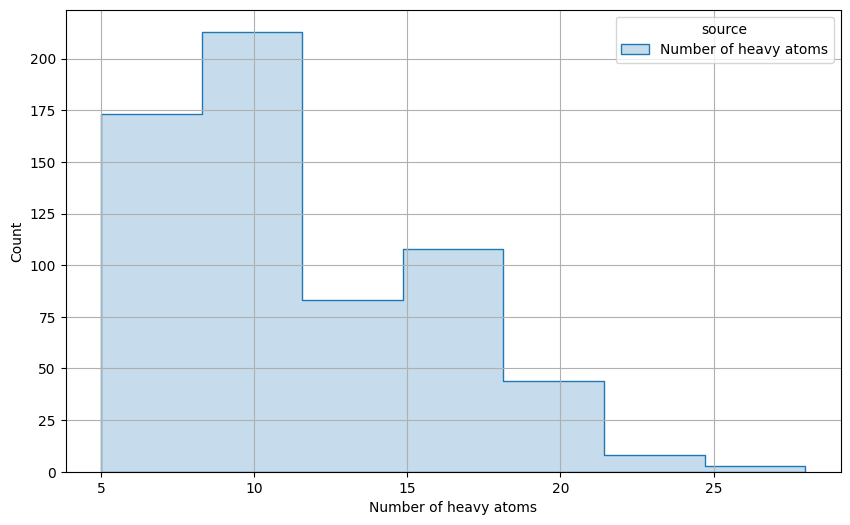

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(l, columns=["Number of heavy atoms"])

df = df.melt(
    var_name="source", value_name="value"
)
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x="value",
    hue="source",
    bins=7,
    kde=False,
    element="step",  
    stat="count",  
    common_norm=False,
)
plt.xlabel("Number of heavy atoms")
plt.ylabel("Count")
plt.grid(True)

#fig = ax.get_figure()   
#fig.savefig("./data/eval/figures/Hist_heavy_atoms_test.png", dpi=300)

plt.show()

In [119]:
print(len(l)/13892)

0.20536999712064496


In [30]:
from tqdm import tqdm

l_ref = []
for i in tqdm(range(len(dataset))):
    selfies = dataset['selfies'][i]
    mol = get_mol(selfies)
    nb = mol.GetNumHeavyAtoms()
    if nb <= 10:
        l_ref.append(i)

100%|██████████| 13892/13892 [02:56<00:00, 78.66it/s]


In [34]:
count = 0
for i in indexes:
    selfies = dataset['selfies'][i]
    mol = get_mol(selfies)
    nb = mol.GetNumHeavyAtoms()
    if nb <= 10:
        count += 1

In [35]:
print (count)
print (len(l_ref))
print (count/len(l_ref))

452
980
0.46122448979591835


In [35]:
count = 0
top = 15
lim = 1
columns = [f"step_{i}_beam_{j}" if i != 0
            else "step_0"
            for i in range(4)
            for j in range(top)
          ]

indexes = [[] for _ in range(4)]
for step in range (4):
    for beam in range(top):
        col = f"step_{step}_beam_{beam}" if step != 0 else "step_0"
        for i in range (len(full_df)):
            if full_df[col][i] >= lim:
                count+=1
                indexes[step].append(i)
                
print (count)

1946


In [36]:
new = [indexes[0]]

for i in range(1, 4):
    print (i)
    new.append(indexes[i] + indexes[i-1])

for i in range(4):
    new[i] = set(new[i])
    print (len(new[i]))

indexes = new

1
2
3
11
370
624
640


[3, 4, 5, 9, 7]


In [37]:
import pandas as pd
df_train = pd.read_csv("./data/eval/nb_heavy_atoms_train.csv")
df_test = pd.read_csv("./data/eval/nb_heavy_atoms_test.csv")
print (df_test)
print (len(df_test))

       Unnamed: 0  nb_heavy_atoms
0               0              39
1               1              18
2               2              35
3               3              30
4               4              15
...           ...             ...
13887       13887               8
13888       13888              23
13889       13889               6
13890       13890              28
13891       13891              28

[13892 rows x 2 columns]
13892


In [38]:
nb_bins = 66
hist_dataset = [0 for _ in range(nb_bins)]
hist_dataset_test = [0 for _ in range(nb_bins)]
hist_preds = [[0 for _ in range(nb_bins)] for _ in range(4)]
max = 66
min = 0
bins = [i * ((max - min)/nb_bins) for i in range(nb_bins)]
bins.append(1000)
print (bins)

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 1000]


In [39]:
from tqdm import tqdm

for i in tqdm(range(len(df_train))):
    nb = df_train['nb_heavy_atoms'][i]
    for j in range(nb_bins):
            if nb >= bins[j] and nb <= bins[j+1]:
                hist_dataset[j] += 1
                break


for k in range(len(indexes)):
    for i in tqdm(range(len(df_test))):
        nb = df_test['nb_heavy_atoms'][i]
        for j in range(nb_bins):
            if nb >= bins[j] and nb <= bins[j+1]:
                if i in indexes[k]:
                    hist_preds[k][j] += 1
                    break
                    

bins = bins[:-1]

100%|██████████| 13892/13892 [00:01<00:00, 8118.77it/s]


In [40]:
print (hist_dataset)
print (hist_preds)
print (sum(hist_preds[3]))

[12, 22, 67, 198, 520, 1141, 1745, 2656, 3530, 4442, 5086, 5749, 5267, 5429, 4833, 4936, 4424, 4941, 4799, 5244, 4907, 3745, 3504, 3811, 3471, 3628, 3334, 3434, 3030, 2931, 2519, 2522, 2126, 1846, 1579, 1428, 1132, 975, 831, 753, 21, 50, 49, 53, 38, 26, 30, 33, 22, 55, 10, 12, 10, 9, 6, 21, 13, 20, 21, 0, 3, 0, 0, 1, 4, 7]
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 2, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 5, 2, 28, 66, 55, 47, 23, 16, 19, 18, 15, 23, 21, 5, 6, 16, 3, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 13, 13, 34, 108, 83, 65, 46, 30, 26, 21, 28, 31, 39, 23, 15, 32, 4, 11, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 12, 15, 32, 108, 87, 70, 48, 36

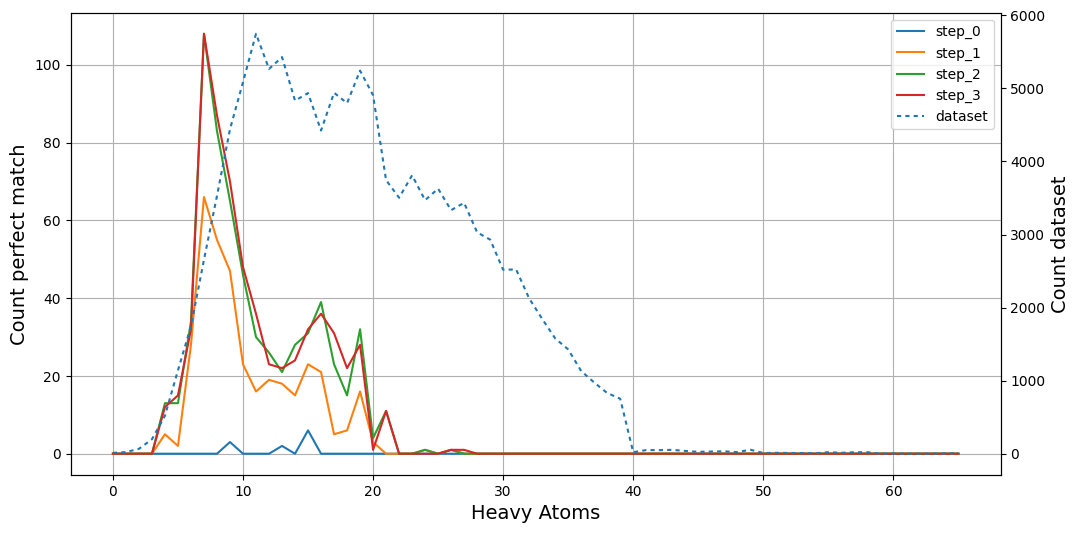

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


l = [
    [
        hist_preds[i][j]
        for j in range(len(hist_preds[0]))
    ]
    for i in range(len(hist_preds))
]

df_twin = pd.DataFrame(hist_dataset, columns=["dataset"])
#df = pd.DataFrame(hist_dataset_test, columns=["dataset_test"])
df = pd.DataFrame(l).T   
df.columns = [f"step_{i}" for i in range(df.shape[1])]  

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=df,
    marker="",
    ax=ax1,
    dashes=False
)

ax2 = ax1.twinx()

sns.lineplot(
    data=df_twin,
    ax=ax2,
    dashes=[(2,2)] 
)

# Labels and title
ax1.set_ylabel("Count perfect match", fontsize=14)
ax1.set_xlabel("Heavy Atoms", fontsize=14)
ax2.set_ylabel("Count dataset", fontsize=14)

# Grid and legend
ax1.grid(True)

leg1 = ax1.get_legend()
h1 = leg1.legend_handles
l1 = [t.get_text() for t in leg1.texts]

leg2 = ax2.get_legend()
h2 = leg2.legend_handles
l2 = [t.get_text() for t in leg2.texts]

handles = h1 + h2
labels = l1 + l2

ax1.legend(handles, labels, title="")
ax2.legend_.remove()

fig.savefig("./data/eval/figures/test_data_repr.png", dpi=300, bbox_inches='tight')

plt.show()

In [6]:
sim = ['tan', 'cosine']
source = ['SELFormer', 
          "SELFormer_WithFormula", 
          "ogSELFormer_PerfectModel_WithFormula", 
          "ogSELFormer_PerfectModel",
         ]

for s in sim:
    for so in source:
        print (f"python -u compute_simils.py --fpgen=ecfp4 --simil_fn={s} --source={so}")
        print ("\n")

python -u compute_simils.py --fpgen=ecfp4 --simil_fn=tan --source=SELFormer


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=tan --source=SELFormer_WithFormula


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=tan --source=ogSELFormer_PerfectModel_WithFormula


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=tan --source=ogSELFormer_PerfectModel


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=cosine --source=SELFormer


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=cosine --source=SELFormer_WithFormula


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=cosine --source=ogSELFormer_PerfectModel_WithFormula


python -u compute_simils.py --fpgen=ecfp4 --simil_fn=cosine --source=ogSELFormer_PerfectModel


